# Quantum Fourier Transform
The QFT is the quantum Discrete Fourier Transform: $QFT|x\rangle=\frac{1}{\sqrt{N}}\sum_y e^{2\pi i xy/N}|y\rangle$.
To *see* it work we use it as a frequency detector — feed in a plane wave that oscillates at frequency $f$ across the register,
and the QFT concentrates all that amplitude onto the single basis state $|f\rangle$, exactly like a classical DFT turning a sine wave into one spike.
Run twice — an ideal simulator and a noisy one carrying a real IBM device's noise model (offline).

In [1]:
# QFT circuit: Hadamard + controlled phase rotations per qubit, then reverse the qubit order
from math import pi
from qiskit import QuantumCircuit

def qft(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n)
    def rotations(k):
        if k == 0:
            return
        k -= 1
        qc.h(k)
        for q in range(k):
            qc.cp(pi / 2 ** (k - q), q, k)   # phase kick from lower qubits
        rotations(k)
    rotations(n)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)                # QFT outputs bits in reversed order
    return qc

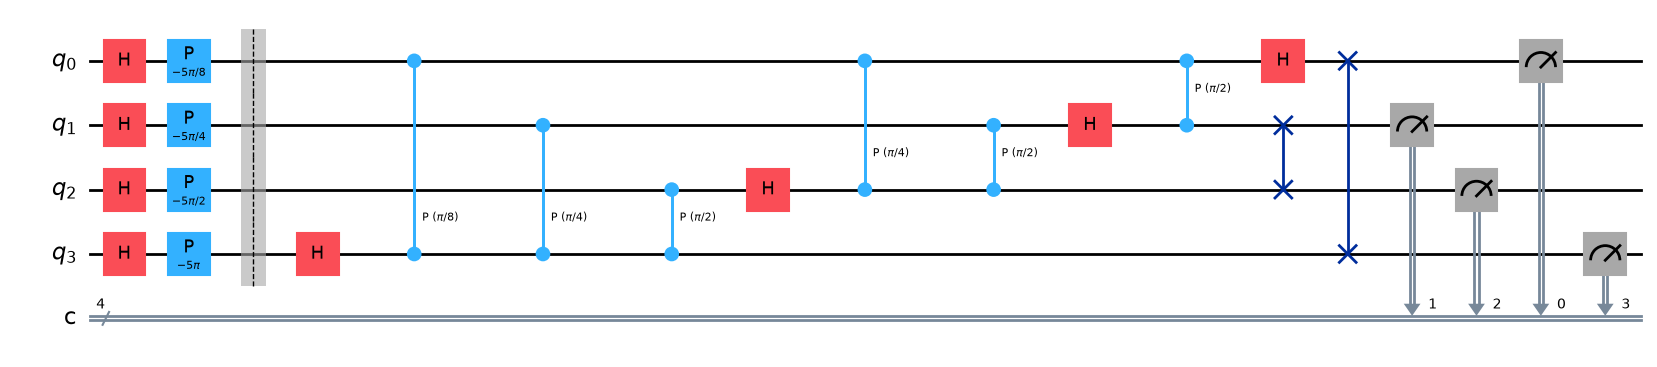

In [2]:
# Prepare a plane wave of frequency f, then apply the QFT to read the frequency back
f = 5                                        # the frequency we expect to recover
n = 4
N = 2 ** n

qc = QuantumCircuit(n, n)
qc.h(range(n))                               # flat superposition over all x
for j in range(n):
    qc.p(-2 * pi * f * (2 ** j) / N, j)      # imprint phases -> plane wave e^{-2πi f x / N}
qc.barrier()
qc.compose(qft(n), inplace=True)             # QFT collapses the wave onto |f>
qc.measure(range(n), range(n))

qc.draw("mpl")

In [3]:
# Run on an ideal simulator and a noisy one (FakeSherbrooke = real IBM device noise model, offline)
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

ideal = AerSimulator()
noisy = AerSimulator.from_backend(FakeSherbrooke())

counts_ideal = ideal.run(transpile(qc, ideal), shots=1024).result().get_counts()
counts_noisy = noisy.run(transpile(qc, noisy, optimization_level=3), shots=1024).result().get_counts()

frequency f : 5
ideal peak  : 0101 = 5
noisy peak  : 0101 = 5


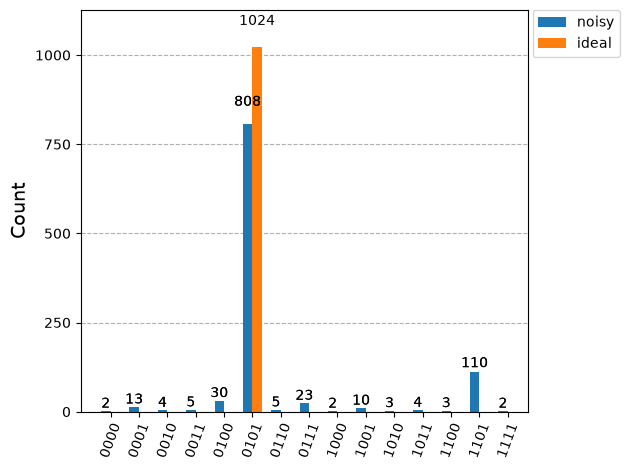

In [4]:
# The dominant bitstring, read as an integer, should equal f
from qiskit.visualization import plot_histogram

peak_ideal = max(counts_ideal, key=counts_ideal.get)
peak_noisy = max(counts_noisy, key=counts_noisy.get)
print("frequency f :", f)
print("ideal peak  :", peak_ideal, "=", int(peak_ideal, 2))
print("noisy peak  :", peak_noisy, "=", int(peak_noisy, 2))
plot_histogram([counts_noisy, counts_ideal], legend=["noisy", "ideal"])

## What the results mean

**The single peak at `0101` (= 5).** We built an input whose amplitudes rotate through the register at frequency `f = 5` — a quantum plane wave, the direct analogue of a classical sine wave sampled at 16 points. The QFT is a change of basis from the *computational* basis (positions) to the *frequency* basis. A pure wave of one frequency has all its weight at that single frequency, so after the QFT the interference is fully constructive on `|5⟩` and fully destructive everywhere else. Measuring therefore returns `0101` almost every time. If you change `f` in the prep cell, the peak moves to match.

**Why this matters more than it looks.** The QFT itself doesn't "solve" anything here — it's a subroutine. But this exact move (encode information into phases, then QFT to turn those phases into a readable number) is the beating heart of Quantum Phase Estimation, and through it, Shor's factoring algorithm. Everything in Phase 2 and 3 of the roadmap is built on the pattern you're seeing in this one histogram.

**Ideal vs. noisy.** The QFT's controlled-phase gates become chains of two-qubit gates after transpilation — the noisiest operation on a real device. The ideal bars sit almost entirely on `0101`; the noisy run (a real IBM device's error model, applied offline) keeps `0101` as the tallest bar but smears weight onto its neighbours. The width of that smear is a direct, visual measure of the accumulated gate error the circuit picks up on hardware.